## Commercial Bank of Ethiopia Review Analysis

Import Required Libraries

In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_2/fintech-review-analytics'))

print('Path set. Python will now look in:', os.path.abspath('C:/Users/dagic/OneDrive/Documents/KAIM/Week_2/fintech-review-analytics'))

Path set. Python will now look in: C:\Users\dagic\OneDrive\Documents\KAIM\Week_2\fintech-review-analytics


In [3]:
# Core libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from collections import Counter
from wordcloud import WordCloud
from datetime import datetime
from google_play_scraper import app, reviews, Sort

# Download necessary NLTK components
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger', 'punkt', 'wordnet']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print("Environment ready ✓")

from src.data_scrapper import scrape_metadata, scrape_reviews, data_quality_check
from src.data_preprocessor import missing_values, duplicate_reviews, check_dateFormat, missing_values, normalize_date, clean_text, invalid_reviews, remove_duplicates, save_cleaned_data, preprocessing_report
from src.modular_nlp_pipeline import modular_nlp_pipeline

print("Libraries loaded successfully!")

Environment ready ✓
Libraries loaded successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Defining Variables

In [4]:
App_Id = "com.combanketh.mobilebanking"
bank = 'CBE'
source = 'Google Play Store'
print(f" Scraping Review for Bank: {bank} with App ID: {App_Id} from Source: {source}")


 Scraping Review for Bank: CBE with App ID: com.combanketh.mobilebanking from Source: Google Play Store


## Mobile App Review Data Scraping from Google Play Store

In [5]:
# Get meta data for the app
scrape_metadata(App_Id, bank)

App Info for CBE
App Title   : Commercial Bank of Ethiopia
Current Score: 4.2855964
Total Ratings: 48,735
Total Reviews: 9,356
Installs     : 10,000,000+


{'title': 'Commercial Bank of Ethiopia',
 'description': 'Commercial Bank of Ethiopia Mobile Banking\r\n\r\nThe Official app of CBE for Android\r\n\r\nCBE Android Mobile application gives you access to your account on your Android phone. Now, you can perform your banking tasks from the palm of your hand, from anywhere at anytime!\r\n\r\nWhat you can do?\r\n- Real time Account Balance\r\n- Account Statement\r\n- Funds Transfer between own account\r\n- Pay to your beneficiaries\r\n- Manage Beneficiary(Add, List and Delete beneficiaries)\r\n- Exchange Rate\r\n- Local Money Transfer using Mobile number\r\n- ATM Locator and much more.\r\n\r\nOnce you download the application, you can get Authorization code and PIN from your CBE Branch at any time.\r\n\r\nFor further information, please e-mail to us :-   MBandIB@cbe.com.et',
 'descriptionHTML': 'Commercial Bank of Ethiopia Mobile Banking<br><br>The Official app of CBE for Android<br><br>CBE Android Mobile application gives you access to your

In [6]:
#scrape 500 reviews for the app
df_reviews, continuation_token = scrape_reviews(App_Id, bank, count=500)
df_reviews = pd.DataFrame(df_reviews)

Collected 500 raw reviews for CBE app.


In [7]:
print(type(df_reviews))

<class 'pandas.DataFrame'>


In [8]:
print(df_reviews.head())
print(df_reviews.columns)

                               reviewId         userName  \
0  e1eaace1-35b5-45d3-99b7-89329b061be8     Yafet Daniel   
1  7e7b2bcf-132d-4469-971b-ebbc396e69bc      Jamal Jamsi   
2  02f1b774-a513-4acb-90f7-c3a187b2eaa7      Nebyou Deme   
3  d945df55-db37-4f77-be9c-d2d290dc65bf       riad jemal   
4  6c401a9f-889f-479e-a212-b37250194bb7  Amamuel Wakjira   

                                           userImage  \
0  https://play-lh.googleusercontent.com/a/ACg8oc...   
1  https://play-lh.googleusercontent.com/a/ACg8oc...   
2  https://play-lh.googleusercontent.com/a/ACg8oc...   
3  https://play-lh.googleusercontent.com/a-/ALV-U...   
4  https://play-lh.googleusercontent.com/a-/ALV-U...   

                                             content  score  thumbsUpCount  \
0                         fast, easy, and save time.      5              0   
1                                      jamal Abarhim      5              0   
2                                     it was good!!!      5         

In [9]:
# Inspect what a single raw review looks like

print("Keys in a single review:")
print(list(df_reviews.iloc[0].keys()))

print("\nFirst raw review (sample):")
for key, value in df_reviews.iloc[0].items():
    print(f"  {key}: {value}")

Keys in a single review:
['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']

First raw review (sample):
  reviewId: e1eaace1-35b5-45d3-99b7-89329b061be8
  userName: Yafet Daniel
  userImage: https://play-lh.googleusercontent.com/a/ACg8ocI1NADrQnvYsW9QtqiMGkfIcqMrgDPXWfn_rjci-V9P_0i0hw=mo
  content: fast, easy, and save time.
  score: 5
  thumbsUpCount: 0
  reviewCreatedVersion: 5.3.0
  at: 2026-05-19 00:24:36
  replyContent: None
  repliedAt: None
  appVersion: 5.3.0


In [10]:
# Step 3: Extract only the columns we need
raw_data = []

for r in df_reviews.itertuples():
    raw_data.append({
        'review_id': r.reviewId,
        'review'   : r.content,
        'rating'   : r.score,
        'date'     : r.at,
        'bank'     : bank,
        'source'   : 'Google Play'
    })

# Build a DataFrame
df_raw = pd.DataFrame(raw_data)

print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (500, 6)


,review_id,review,rating,date,bank,source
0,e1eaace1-35b5-45d3-99b7-89329b061be8,"fast, easy, and save time.",5,2026-05-19 00:24:36,CBE,Google Play
1,7e7b2bcf-132d-4469-971b-ebbc396e69bc,jamal Abarhim,5,2026-05-18 21:13:42,CBE,Google Play
2,02f1b774-a513-4acb-90f7-c3a187b2eaa7,it was good!!!,5,2026-05-18 19:31:26,CBE,Google Play
3,d945df55-db37-4f77-be9c-d2d290dc65bf,CBE our pride,5,2026-05-18 17:49:05,CBE,Google Play
4,6c401a9f-889f-479e-a212-b37250194bb7,i love this bank and mobile banking of Comerci...,5,2026-05-18 15:33:39,CBE,Google Play


## Exploring the Raw Data

In [11]:
# Basic shape and types
print(f"Total reviews collected: {len(df_raw)}")
print(f"\nColumn dtypes:")
print(df_raw.dtypes)

Total reviews collected: 500

Column dtypes:
review_id               str
review                  str
rating                int64
date         datetime64[us]
bank                    str
source                  str
dtype: object


In [12]:
print("Rating Distribution:")
rating_counts = df_raw['rating'].value_counts().sort_index(ascending=False)
for rating, count in rating_counts.items():
    bar = '█' * (count // 4) 
    print(f"{rating} stars: {bar} ({count} reviews)")


Rating Distribution:
5 stars: ████████████████████████████████████████████████████████████████████████████████████ (339 reviews)
4 stars: ██████████ (43 reviews)
3 stars: ███████ (31 reviews)
2 stars: ███ (12 reviews)
1 stars: ██████████████████ (75 reviews)


In [13]:
# What does the date column look like right now?
print("Sample date values (raw):")
print(df_raw['date'].head(10).to_string())

print(f"\nDate dtype: {df_raw['date'].dtype}")

Sample date values (raw):
0   2026-05-19 00:24:36
1   2026-05-18 21:13:42
2   2026-05-18 19:31:26
3   2026-05-18 17:49:05
4   2026-05-18 15:33:39
5   2026-05-18 13:31:59
6   2026-05-18 10:56:04
7   2026-05-18 10:46:02
8   2026-05-18 10:13:24
9   2026-05-18 09:22:01

Date dtype: datetime64[us]


## Data Quality Audit

In [14]:
data_quality_check(df_raw)

Data Quality Check:
------------------------------
Total reviews collected: 500
Missing values per column:
review_id    0
review       0
rating       0
date         0
bank         0
source       0
dtype: int64


In [15]:
missing_values(df_raw)

Removed 0 rows with missing critical data
Remaining: 500 reviews


,review_id,review,rating,date,bank,source
0,e1eaace1-35b5-45d3-99b7-89329b061be8,"fast, easy, and save time.",5,2026-05-19 00:24:36,CBE,Google Play
1,7e7b2bcf-132d-4469-971b-ebbc396e69bc,jamal Abarhim,5,2026-05-18 21:13:42,CBE,Google Play
2,02f1b774-a513-4acb-90f7-c3a187b2eaa7,it was good!!!,5,2026-05-18 19:31:26,CBE,Google Play
3,d945df55-db37-4f77-be9c-d2d290dc65bf,CBE our pride,5,2026-05-18 17:49:05,CBE,Google Play
4,6c401a9f-889f-479e-a212-b37250194bb7,i love this bank and mobile banking of Comerci...,5,2026-05-18 15:33:39,CBE,Google Play
...,...,...,...,...,...,...
495,1934266d-d352-4231-b910-d8449631c31a,it's good,3,2026-03-09 09:20:53,CBE,Google Play
496,c6885e9d-715b-4b84-bf1c-ad701607bcb7,easy to use,5,2026-03-09 09:09:51,CBE,Google Play
497,5eaa3d58-f4b6-47ba-a046-8a21b8106f39,good,5,2026-03-09 00:13:02,CBE,Google Play
498,631a6a75-2a40-4963-b622-d357cc000e2b,Very Good service,5,2026-03-08 18:29:13,CBE,Google Play


Check for Duplicates

In [16]:
duplicate_reviews(df_raw)

Duplicate reviews:
------------------------------
Total duplicate review IDs: 0
Total duplicate review texts: 145
Total empty reviews: 0
Total duplicate reviews: 0


In [17]:
# Copying the raw DataFrame to work on a clean version
df = df_raw.copy()
print("Data copied for preprocessing.")

Data copied for preprocessing.


Remove Missing Data

In [18]:
df = missing_values(df)

Removed 0 rows with missing critical data
Remaining: 500 reviews


Remove Duplicates

In [19]:
df = remove_duplicates(df)

Removed 0 duplicate reviews based on review_id
Remaining: 500 reviews


Normalize Date

In [20]:
check_dateFormat(df)
df = normalize_date(df)


Checking date format:
------------------------------
Sample dates: 2026-05-19 00:24:36
Data type of 'date' column: datetime64[us]
  Target format: YYYY-MM-DD (string or date object)
Dates normalized to YYYY-MM-DD format
dtype: str

Date range: 2026-03-08 to 2026-05-19


Clean white spaces

In [21]:
df = clean_text(df)

Remove Invalid Reviews

In [22]:
df = invalid_reviews(df)

Invalid ratings (outside 1–5): 0
Remaining reviews after removing invalid ratings: 500
Data type of 'rating' column: int64


## Cleaned Data

In [23]:
# Select only the 5 required columns in the right order
df_clean = df[['review', 'rating', 'date', 'bank', 'source']].copy()

# Sort by date (newest first) for clean presentation
df_clean = df_clean.sort_values('date', ascending=False).reset_index(drop=True)

print(f"Final dataset shape: {df_clean.shape}")
df_clean.head(10)

Final dataset shape: (500, 5)


,review,rating,date,bank,source
0,"fast, easy, and save time.",5,2026-05-19,CBE,Google Play
1,simple to use,5,2026-05-18,CBE,Google Play
2,What an excellent app with smooth performance !!,5,2026-05-18,CBE,Google Play
3,pels,5,2026-05-18,CBE,Google Play
4,👌👌👌,5,2026-05-18,CBE,Google Play
5,I have an account of cbe when i open the accou...,1,2026-05-18,CBE,Google Play
6,Good,5,2026-05-18,CBE,Google Play
7,good,5,2026-05-18,CBE,Google Play
8,commerali bank,1,2026-05-18,CBE,Google Play
9,jamal Abarhim,5,2026-05-18,CBE,Google Play


Save Cleaned Data

In [24]:
df = save_cleaned_data(df, "cbe_reviews")

Shape of cleaned cbe_reviews: (500, 6)
First 5 rows of cleaned cbe_reviews:
                              review_id  \
0  e1eaace1-35b5-45d3-99b7-89329b061be8   
1  7e7b2bcf-132d-4469-971b-ebbc396e69bc   
2  02f1b774-a513-4acb-90f7-c3a187b2eaa7   
3  d945df55-db37-4f77-be9c-d2d290dc65bf   
4  6c401a9f-889f-479e-a212-b37250194bb7   

                                              review  rating        date bank  \
0                         fast, easy, and save time.       5  2026-05-19  CBE   
1                                      jamal Abarhim       5  2026-05-18  CBE   
2                                     it was good!!!       5  2026-05-18  CBE   
3                                      CBE our pride       5  2026-05-18  CBE   
4  i love this bank and mobile banking of Comerci...       5  2026-05-18  CBE   

        source  
0  Google Play  
1  Google Play  
2  Google Play  
3  Google Play  
4  Google Play  


## Report for Data Preprocessing

In [25]:
preprocessing_report(df_raw, df)

  PREPROCESSING REPORT — Reviews

  Raw reviews collected  :    500
  Reviews after cleaning :    500
  Reviews removed        :      0
  Data retention rate    : 100.0%
  Data quality           : EXCELLENT

  Date range : 2026-03-08  to  2026-05-19

  Rating distribution:
    5 stars :  339 (67.8%)  ███████████████████████████████████████████████████████████████████
    4 stars :   43 ( 8.6%)  ████████
    3 stars :   31 ( 6.2%)  ██████
    2 stars :   12 ( 2.4%)  ██
    1 stars :   75 (15.0%)  ███████████████

  Text length stats:
    Min    : 1 characters
    Median : 13 characters
    Max    : 499 characters

  Columns in final CSV:
    - review_id
    - review
    - rating
    - date
    - bank
    - source



## Tokenization and Lemmatization

In [26]:
def modular_nlp_pipeline(text):
    # 1. Cleaning
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Stop-word removal & Lemmatization
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    processed = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(processed)

# Apply cleaning
print("Running modular preprocessing...")
df_raw['clean_text'] = df_raw['review'].apply(modular_nlp_pipeline)

# Drop invalid/too short reviews
df_clean = df_raw[df_raw['clean_text'].str.len() > 2].copy()
print(f"Final cleaned dataset size: {len(df_clean)}")

Running modular preprocessing...


Final cleaned dataset size: 456


## Keyword Extraction

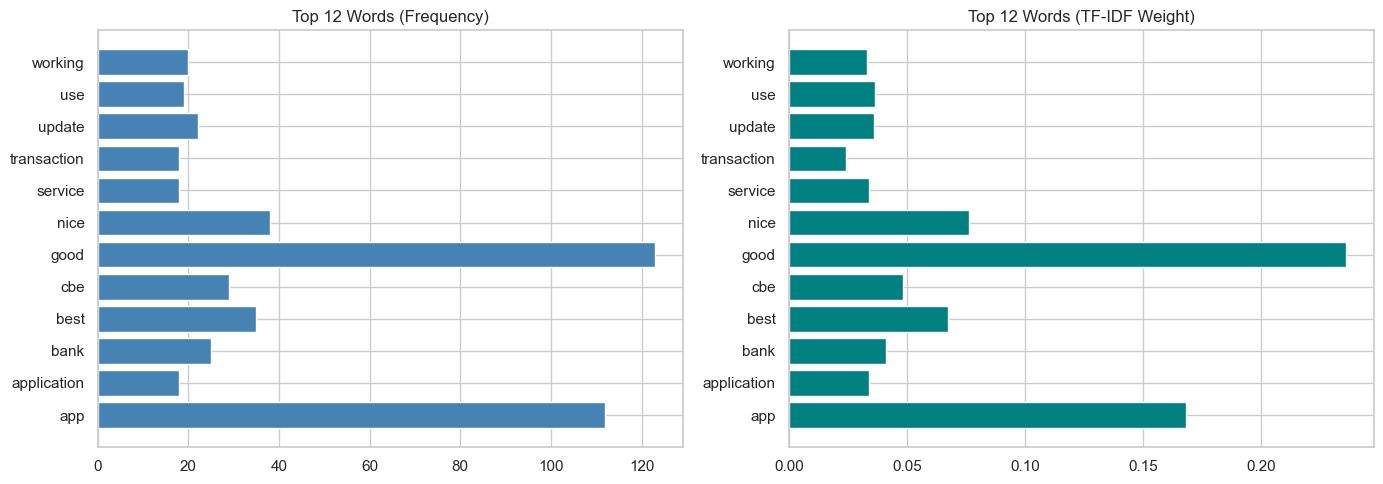

In [27]:
# Frequency (BoW) vs TF-IDF
tfidf_vec = TfidfVectorizer(max_features=12, stop_words='english')
X_tfidf = tfidf_vec.fit_transform(df_clean['clean_text'])

cv_vec = CountVectorizer(max_features=12, stop_words='english')
X_cv = cv_vec.fit_transform(df_clean['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cv_vec.get_feature_names_out(), X_cv.toarray().sum(axis=0), color='steelblue')
axes[0].set_title('Top 12 Words (Frequency)')

axes[1].barh(tfidf_vec.get_feature_names_out(), X_tfidf.toarray().mean(axis=0), color='teal')
axes[1].set_title('Top 12 Words (TF-IDF Weight)')

plt.tight_layout(); plt.show()

## N-gram Analysis


C:\Users\dagic\AppData\Local\Temp\ipykernel_2532\40103568.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
C:\Users\dagic\AppData\Local\Temp\ipykernel_2532\40103568.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')


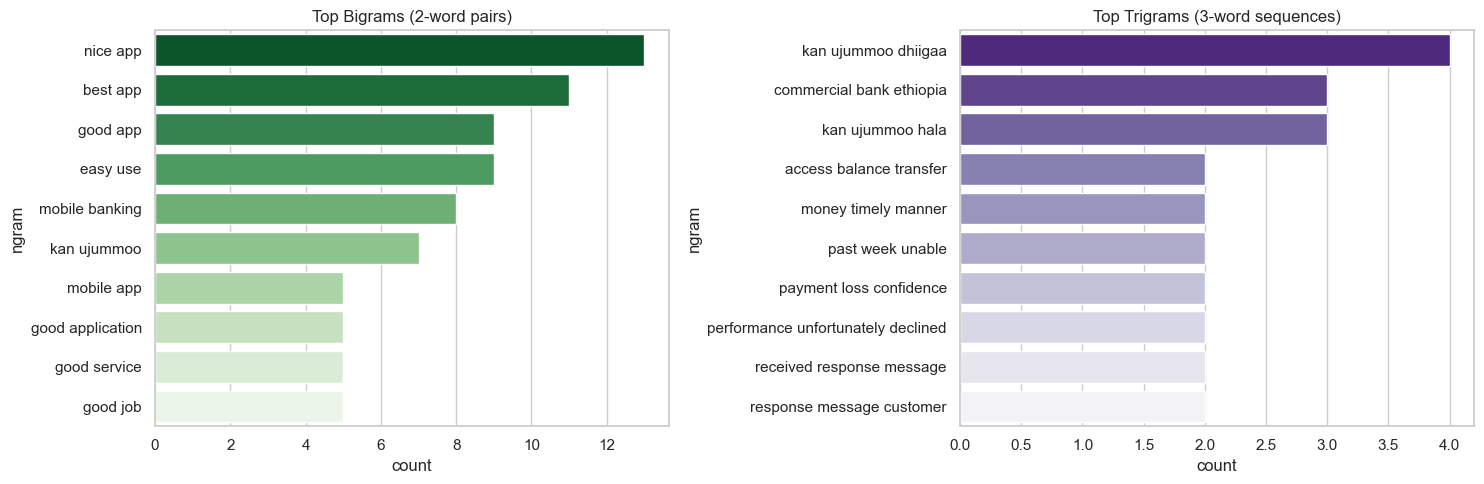

In [28]:
def get_top_ngrams(corpus, n, k=10):
    vec = CountVectorizer(ngram_range=(n,n), max_features=100)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    return pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(k)

bi = get_top_ngrams(df_clean['clean_text'], 2)
tri = get_top_ngrams(df_clean['clean_text'], 3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top Bigrams (2-word pairs)')
sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top Trigrams (3-word sequences)')
plt.tight_layout(); plt.show()

## POS Tagging and Noun Extraction

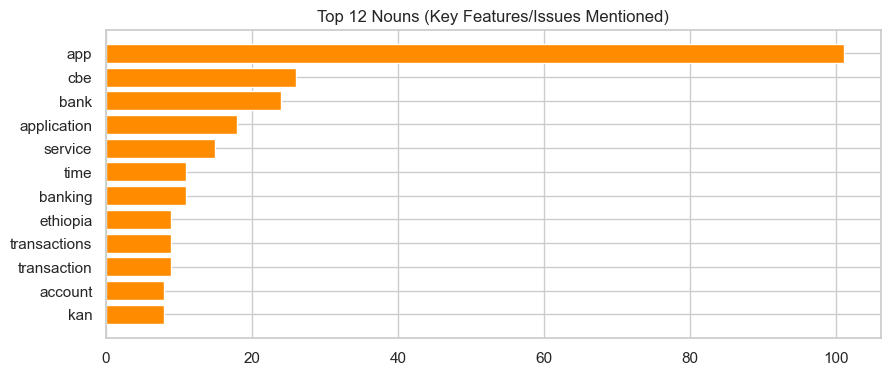

In [29]:
# Identifying Product Features (Nouns)
import nltk
from nltk import word_tokenize, pos_tag
from collections import Counter
import matplotlib.pyplot as plt

# Download the specific tagger if it's not already downloaded
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def extract_nouns(text):
    tokens = word_tokenize(text)
    return [w.lower() for w, p in pos_tag(tokens) if p.startswith('NN') and len(w) > 2 and w.lower() not in stop_words]

df_clean['nouns'] = df_clean['review'].apply(extract_nouns)
all_nouns = [n for ns in df_clean['nouns'] for n in ns]
noun_counts = Counter(all_nouns).most_common(12)

plt.figure(figsize=(10, 4))
plt.barh([x[0] for x in noun_counts][::-1], [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns (Key Features/Issues Mentioned)')
plt.show()

## Word Cloud

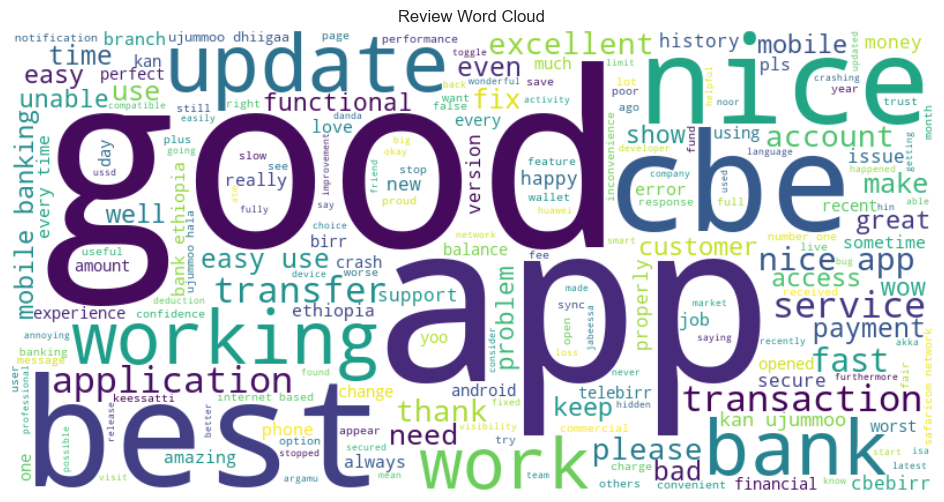

In [30]:
# Cell 8: Word Cloud
text_combined = " ".join(df_clean['clean_text'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud')
plt.show()

## Multi-Model Sentiment Analysis

In [31]:
# Sentiment Application
df_clean['vader_compound'] = df_clean['review'].apply(lambda x: sia.polarity_scores(x)['compound'])
df_clean['tb_polarity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_clean['tb_subjectivity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

def get_label(s):
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

df_clean['sentiment'] = df_clean['vader_compound'].apply(get_label)
print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))

VADER Distribution:
 sentiment
positive    0.68
neutral     0.20
negative    0.12
Name: proportion, dtype: float64


#### Interpretation
    The Vader distrubition showed that:
        - 68% of the total review are positive
        - 20% is neutral
        - 12% is negative
    ** this 12% of negative reviews should be analysed carefully, as it might be a bottleneck for the operational service delivery for the fintech companies.